# 4. Training and model selection

Entrenamos tres familias de modelos y seleccionamos el campeón usando exclusivamente validación cruzada sobre entrenamiento. Cada candidato incluye su propio preprocesamiento.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd "/content/drive/MyDrive/Courses/SI3003 - Inteligencia Artificial/Clase06/Classification"

/content/drive/MyDrive/Courses/SI3003 - Inteligencia Artificial/Clase06/Classification


In [3]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [9]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"
for directory in (DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

In [10]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
contract = json.loads((ARTIFACTS_DIR / "data_contract.json").read_text(encoding="utf-8"))
preprocessors = joblib.load(ARTIFACTS_DIR / "preprocessors.joblib")

X_train = train_df[contract["features"]]
y_train = train_df[contract["target"]]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## Repaso: entropía

Un árbol puede seleccionar la división que produzca mayor reducción de entropía:

$$B(p)=-p\log_2(p)-(1-p)\log_2(1-p).$$

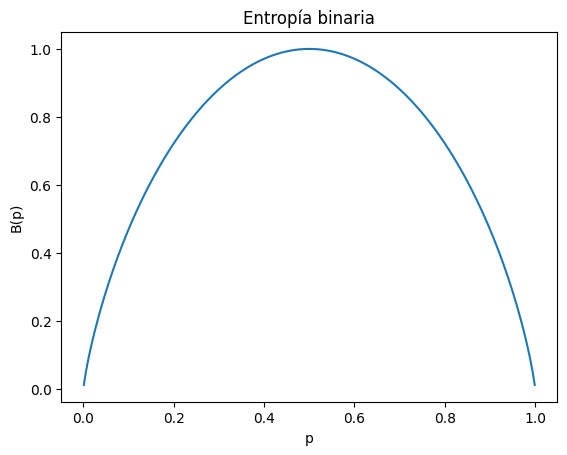

In [11]:
def binary_entropy(p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

p = np.linspace(0.001, 0.999, 200)
plt.plot(p, binary_entropy(p))
plt.xlabel("p")
plt.ylabel("B(p)")
plt.title("Entropía binaria")
plt.show()

## Candidatos y espacios de búsqueda

In [12]:
candidates = {
    "decision_tree": (
        Pipeline([
            ("preprocessing", clone(preprocessors["tree"])),
            ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE)),
        ]),
        {
            "classifier__criterion": ["gini", "entropy"],
            "classifier__max_depth": [2, 3, 4, 5, 6, 8, None],
            "classifier__min_samples_split": [2, 5, 10, 20],
        },
    ),
    "logistic_regression": (
        Pipeline([
            ("preprocessing", clone(preprocessors["scaled"])),
            ("classifier", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
        ]),
        {"classifier__C": [0.01, 0.1, 1, 10, 100]},
    ),
    "knn": (
        Pipeline([
            ("preprocessing", clone(preprocessors["scaled"])),
            ("classifier", KNeighborsClassifier()),
        ]),
        {
            "classifier__n_neighbors": [3, 5, 7, 9, 11, 15],
            "classifier__weights": ["uniform", "distance"],
        },
    ),
}

In [13]:
searches = {}
rows = []

for name, (pipeline, param_grid) in candidates.items():
    search = GridSearchCV(
        pipeline,
        param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        return_train_score=True,
    )
    search.fit(X_train, y_train)
    searches[name] = search
    rows.append({
        "model": name,
        "cv_roc_auc": search.best_score_,
        "best_params": json.dumps(search.best_params_),
    })

comparison = pd.DataFrame(rows).sort_values("cv_roc_auc", ascending=False).reset_index(drop=True)
comparison

,model,cv_roc_auc,best_params
0,logistic_regression,0.995872,"{""classifier__C"": 1}"
1,knn,0.992518,"{""classifier__n_neighbors"": 11, ""classifier__w..."
2,decision_tree,0.963880,"{""classifier__criterion"": ""entropy"", ""classifi..."


In [14]:
champion_name = comparison.loc[0, "model"]
champion = searches[champion_name].best_estimator_

comparison.to_csv(REPORTS_DIR / "cv_model_comparison.csv", index=False)
joblib.dump(champion, ARTIFACTS_DIR / "champion_model.joblib")

training_metadata = {
    "champion": champion_name,
    "selection_metric": "roc_auc",
    "cv_folds": 5,
    "cv_score": float(searches[champion_name].best_score_),
    "best_params": searches[champion_name].best_params_,
}
(ARTIFACTS_DIR / "training_metadata.json").write_text(
    json.dumps(training_metadata, indent=2), encoding="utf-8"
)
print("Modelo campeón:", champion_name)
print("ROC AUC CV:", round(training_metadata["cv_score"], 4))

Modelo campeón: logistic_regression
ROC AUC CV: 0.9959


## Inspección opcional del árbol

In [15]:
tree = champion.named_steps["classifier"]
plt.figure(figsize=(18, 8))
plot_tree(
    tree,
    feature_names=contract["features"],
    class_names=contract["target_names"],
    filled=True,
)
plt.show()


El árbol no fue el modelo campeón; no se utiliza esta visualización para seleccionarlo.
